In [1]:
	
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.modeling import models, fitting
fitter = fitting.LinearLSQFitter()
from scipy.ndimage import median_filter
from tqdm import tqdm
from random import gauss
from scipy.interpolate import interp1d

In [2]:
Oct2015='../Spectra/B103/FEROS_2015OCT/ADP.2016-09-28T06:54:52.145.fits'
Dec2015='../Spectra/B103/FEROS_2015DEC/ADP.2016-09-28T06:54:49.594.fits'
Jul2016='../Spectra/B103/FEROS_2016JUL/ADP.2016-09-28T11:26:18.933.fits'


In [3]:
#fits.getheader(Oct2015)

In [4]:
data1=fits.getdata(Oct2015)
data2=fits.getdata(Dec2015)
data3=fits.getdata(Jul2016)
data3

FITS_rec([([3527.51999997, 3527.54999997, 3527.57999997, ..., 9216.6898728 , 9216.7198728 , 9216.7498728 ], [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,  1.71294913e-03,  6.24866807e-04,  0.00000000e+00], [nan, nan, nan, ..., nan, nan, nan])],
         dtype=(numpy.record, [('WAVE', '>f8', (189642,)), ('FLUX', '>f4', (189642,)), ('ERR', '>f4', (189642,))]))

(0.0, 2.0)

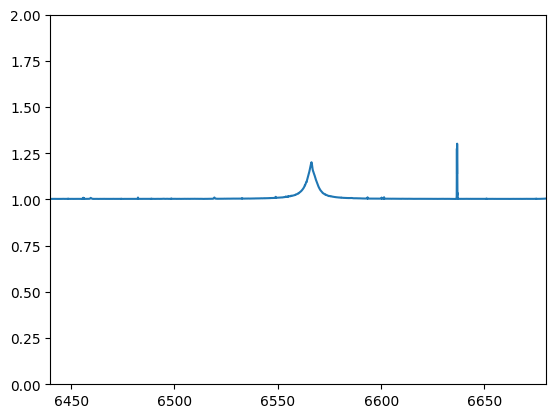

In [5]:
plt.plot(data1['WAVE'][0],data1['FLUX'][0]+1)
plt.xlim(6440, 6680)
plt.ylim(0,2)

In [14]:
#Data October 2015
xd1_new=data1['FLUX'][0]+1
xd1_filt=median_filter(xd1_new,10)
lam1 = data1['WAVE'][0]

mask_alpha1=np.abs(6562.8-lam1)>40
mask_beta1=np.abs(4861.33333333333-lam1)>40
mask_gamma1=np.abs(4367.23-lam1)>50 #H_gamma está corrido
mask1=mask_alpha1&mask_beta1&mask_gamma1

#Data December 2015
xd2_new=data2['FLUX'][0]+1
xd2_filt=median_filter(xd2_new,10)
lam2 = data2['WAVE'][0]

mask_alpha2=np.abs(6562.8-lam2)>40
mask_beta2=np.abs(4861.33333333333-lam2)>40
mask_gamma2=np.abs(4367.23-lam2)>50 #H_gamma está corrido
mask2=mask_alpha2&mask_beta2&mask_gamma2

#Data July 2016
xd3_new=data3['FLUX'][0]+1
xd3_filt=median_filter(xd3_new,10)
lam3 = data3['WAVE'][0]

mask_alpha3=np.abs(6562.8-lam3)>40
mask_beta3=np.abs(4861.33333333333-lam3)>40
mask_gamma3=np.abs(4367.23-lam3)>50 #H_gamma está corrido
mask3=mask_alpha3&mask_beta3&mask_gamma3

In [15]:
modelo1 = fitter(models.Chebyshev1D(25),lam1[mask1],xd1_filt[mask1])
modelo2 = fitter(models.Chebyshev1D(25),lam2[mask2],xd2_filt[mask2])
modelo3 = fitter(models.Chebyshev1D(25),lam3[mask3],xd3_filt[mask3])


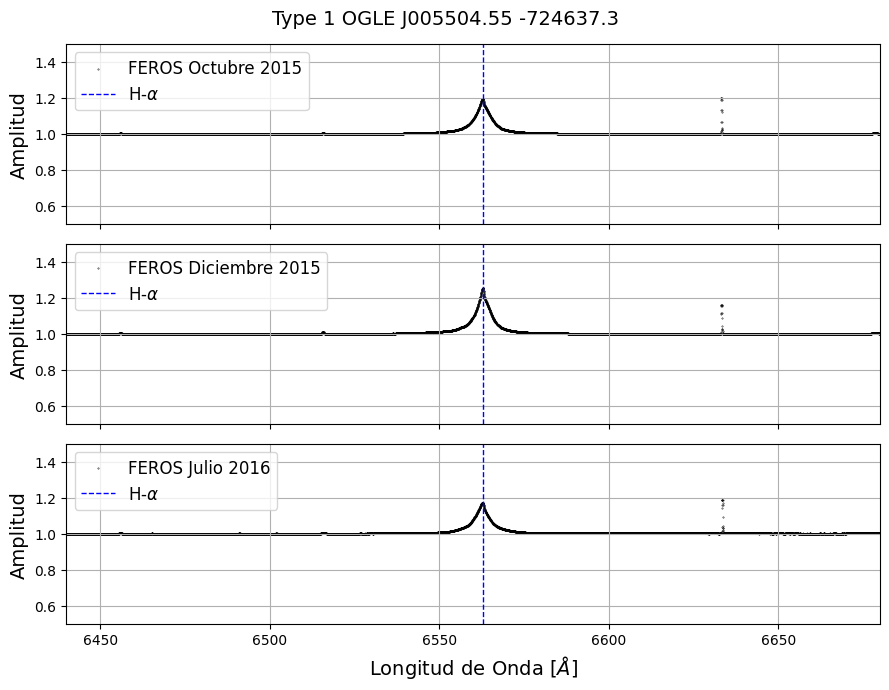

In [16]:
fig, axs = plt.subplots(3, 1, sharex=True, figsize=(9, 7))  # 5 rows, 1 column

# Plot each light curve
axs[0].scatter(lam1-3.5,xd1_filt/modelo1(lam1),s=0.1, color='black', label='FEROS Octubre 2015')
axs[1].scatter(lam2-3.5,xd2_filt/modelo2(lam2), s=0.1, color='black',label='FEROS Diciembre 2015')
axs[2].scatter(lam3-3.5,xd3_filt/modelo3(lam3), s=0.1, color='black',label='FEROS Julio 2016')



# Labels
for ax in axs:
    ax.set_ylabel('Amplitud',fontsize=14) 
    ax.axvline(x=6562.8, color='blue', linestyle='--', linewidth=1,label=r'H-$\alpha$')
    ax.axvline(x=4861.3, color='blue', linestyle='--', linewidth=1)
    ax.legend(loc='upper left', fontsize=12)
    ax.grid(True)
axs[-1].set_xlabel(r'Longitud de Onda [$\AA$]',fontsize=14)
axs[-1].set_xlim(6440, 6680)
#axs[-1].set_xlim(4740, 4980)#H-beta
axs[0].set_ylim(0.5, 1.5)
axs[1].set_ylim(0.5, 1.5)
axs[2].set_ylim(0.5,1.5)

fig.suptitle('Type 1 OGLE J005504.55 -724637.3',fontsize=14)
plt.tight_layout()
plt.savefig('B103')
plt.show()

In [43]:
wb= 20 #Ancho banda azul
cb= 6530 #Posición banda azul
cr= 6590 #Posición roja
wr= 20 #Ancho banda roja
wf= 30 #Ancho banda emisión
cf = 6562.8 #Posición banda emisión
n_iter = 100

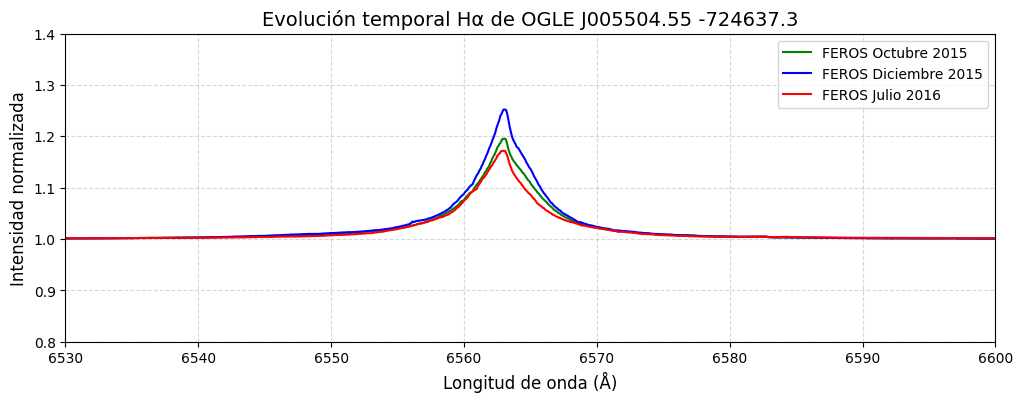

In [44]:
EW_sst = []
#with fits.open(Oct2015) as hdul:
h1 = fits.getheader(Oct2015)                            
fl = (xd1_filt/modelo1(lam1))[98900:-86000] #Flux normalizado
efl = data1['ERR'][0]
wl = (lam1-3.3)[98900:-86000] #wavelength

plt.figure(figsize=(12,4))
        
plt.plot(wl, fl,color='green',label='FEROS Octubre 2015')
plt.plot((lam2-3.3),(xd2_filt/modelo2(lam2)),color='blue',label='FEROS Diciembre 2015')
plt.plot((lam3-3.3),(xd3_filt/modelo3(lam3)),color='red', label='FEROS Julio 2016')

#plt.fill_between([center_2013+0.3-2.071798488876922/2,center_2013+0.3+2.071798488876922/2], 0.65,1, color='blue', alpha=0.2)
#plt.axvline(x=6562.8, color='blue', linestyle='--', linewidth=1,label=r'H-$\alpha$')
#plt.axvline(x=6545.6, color='red', linestyle='--', linewidth=1)
#plt.axvline(x=6575.6, color='red', linestyle='--', linewidth=1)

plt.xlabel('Longitud de onda (Å)', fontsize=12)
plt.ylabel('Intensidad normalizada', fontsize=12)
plt.title('Evolución temporal Hα de OGLE J005504.55 -724637.3', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.xlim(6530,6600)
plt.ylim(0.8,1.4)
plt.savefig('B103Variabl')
plt.show()

SampleEW = []
        

In [45]:
def EW (wl, fl, cf, wf, cb, wb, cr, wr, n_iter):
    
    ratc = (cf-cb)/(cr-cb) #Término denominador de la ecuación de Hernandez et al.
    EWs = []
    
    for n in range(n_iter):

        #Formar banda emisión
        whf = np.where([(wl>cf-wf/2) & (wl<cf+wf/2)])[1]
        yf = [gauss(i, np.sqrt(i)) for i in fl[whf]]
        #np.abs(i)

        #Formar banda azul
        whb = np.where([(wl> cb-wb/2) & (wl< cb+wb/2)])[1]
        yb = [gauss(i, np.sqrt(i)) for i in fl[whb]]

        #Formar banda roja
        whr = np.where([(wl> cr-wr/2) & (wl< cr+wr/2)])[1]
        yr = [gauss(i, np.sqrt(i)) for i in fl[whr]]

        if np.isnan(yf).any() or np.isnan(yb).any() or np.isnan(yr).any():
            continue
        
        else:
        
            Ff = np.mean(yf)
            Fb = np.mean(yb)
            Fr = np.mean(yr)

            EWi = - wf * (1 - (Ff / ( Fb + ratc*(Fr - Fb))))

        EWs.append(EWi)

    EW = np.mean(np.array(EWs)[~np.isnan(EWs)])
    sEW = np.std(np.array(EWs)[~np.isnan(EWs)])
    return EW,sEW

In [78]:
EWmeOct2015 = EW(wl, fl, cf, wf, cb, wb, cr, wr, n_iter)
EWmeOct2015


(1.5291021936391567, 1.2860514542166197)

In [70]:
EWmeDic2015 = EW((lam2-3.5)[98900:-86000], (xd2_filt/modelo2(lam2))[98900:-86000], cf, wf, cb, wb, cr, wr, n_iter)
EWmeDic2015

(1.6979731185213354, 1.408600246646521)

In [82]:
EWmeJul2016 = EW((lam3-3.5)[98900:-86000], (xd3_filt/modelo3(lam3))[98900:-86000], cf, wf, cb, wb, cr, wr, n_iter)
EWmeJul2016

(1.2708344284661306, 1.1251221048164126)

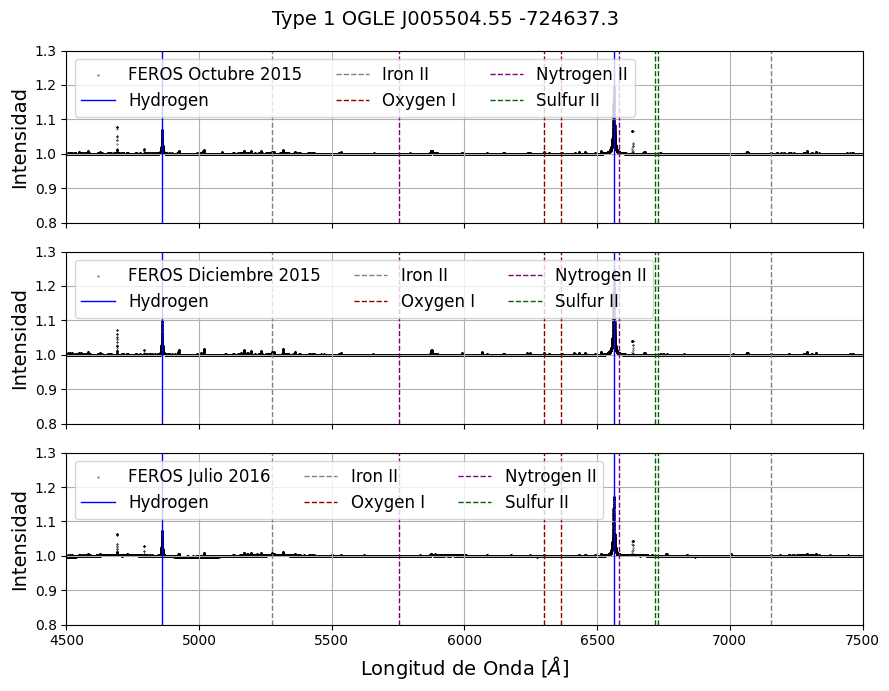

In [120]:
fig, axs = plt.subplots(3, 1, sharex=True, figsize=(9, 7))  # 5 rows, 1 column

# Plot each light curve
axs[0].scatter(lam1-3.6,xd1_filt/modelo1(lam1),s=0.1, color='black', label='FEROS Octubre 2015')
axs[1].scatter(lam2-3.6,xd2_filt/modelo2(lam2), s=0.1, color='black',label='FEROS Diciembre 2015')
axs[2].scatter(lam3-3.6,xd3_filt/modelo3(lam3), s=0.1, color='black',label='FEROS Julio 2016')



# Labels
for ax in axs:
    ax.set_ylabel('Intensidad',fontsize=14) 
    ax.axvline(x=6562.8, color='blue', linestyle='-', linewidth=1,label=r'Hydrogen')
    ax.axvline(x=4861.3, color='blue', linestyle='-', linewidth=1)
    ax.axvline(x=7155, color='gray', linestyle='--', linewidth=1,label=r'Iron II')
    ax.axvline(x=4244, color='gray', linestyle='--', linewidth=1)
    ax.axvline(x=4287, color='gray', linestyle='--', linewidth=1)
    ax.axvline(x=4415, color='gray', linestyle='--', linewidth=1)
    ax.axvline(x=5273, color='gray', linestyle='--', linewidth=1)
    ax.axvline(x=6300, color='darkred', linestyle='--', linewidth=1,label=r'Oxygen I')
    ax.axvline(x=6363, color='darkred', linestyle='--', linewidth=1)
    ax.axvline(x=5755, color='purple', linestyle='--', linewidth=1,label=r'Nytrogen II')
    ax.axvline(x=6584, color='purple', linestyle='--', linewidth=1)
    ax.axvline(x=4068, color='darkgreen', linestyle='--', linewidth=1,label=r'Sulfur II')
    ax.axvline(x=6717, color='darkgreen', linestyle='--', linewidth=1)
    ax.axvline(x=6730, color='darkgreen', linestyle='--', linewidth=1)
    ax.legend(loc='upper left', fontsize=12,ncol=3)
    ax.grid(True)
axs[-1].set_xlabel(r'Longitud de Onda [$\AA$]',fontsize=14)
axs[-1].set_xlim(4500, 7500)
axs[0].set_ylim(0.8, 1.3)
axs[1].set_ylim(0.8, 1.3)
axs[2].set_ylim(0.8,1.3)

fig.suptitle('Type 1 OGLE J005504.55 -724637.3',fontsize=14)
plt.tight_layout()
plt.savefig('B103_full')
plt.show()

## Ancho equivalente usando FHWM

In [23]:
def center_half_min_and_EW(x, y):
    min_idx = np.argmin(y)
    min_x = x[min_idx]
    min_y = y[min_idx]

    # Estimación del baseline
    left = y[:min_idx]
    right = y[min_idx+1:]
    baseline = 1

    # Estimación del ruido (std) en el continuo
    noise_std = np.std(np.concatenate([left[-5:], right[:5:]]))

    # Altura en FWHM
    half_depth = (baseline + min_y) / 2

    x_dense = np.linspace(x[0], x[-1], 10000)
    f_interp = interp1d(x, y, kind='linear')
    y_dense = f_interp(x_dense)

    # Centro en FWHM
    y_half = y_dense - half_depth
    crossings = np.where(np.diff(np.sign(y_half)))[0]

    if len(crossings) >= 2:
        x1 = x_dense[crossings[0]]
        x2 = x_dense[crossings[-1]]
        center = (x1 + x2) / 2
    else:
        x1, x2 = x_dense[0], x_dense[-1]
        center = min_x

    # Ancho equivalente
    delta_x = x_dense[1] - x_dense[0]
    normalized = 1 - (y_dense / baseline)
    ew = np.sum(normalized * delta_x)

    # Error
    in_line = (x_dense >= x1) & (x_dense <= x2)
    N = np.sum(in_line)
    ew_error = delta_x * np.sqrt(N) * (noise_std / baseline)

    return center, x1, x2, ew, ew_error

Ancho equivalente Oct 2015: -1.451554 ± 0.000050
Ancho equivalente Dec 2015: -1.709653 ± 0.000056
Ancho equivalente Jul 2016: -1.365651 ± 0.000153


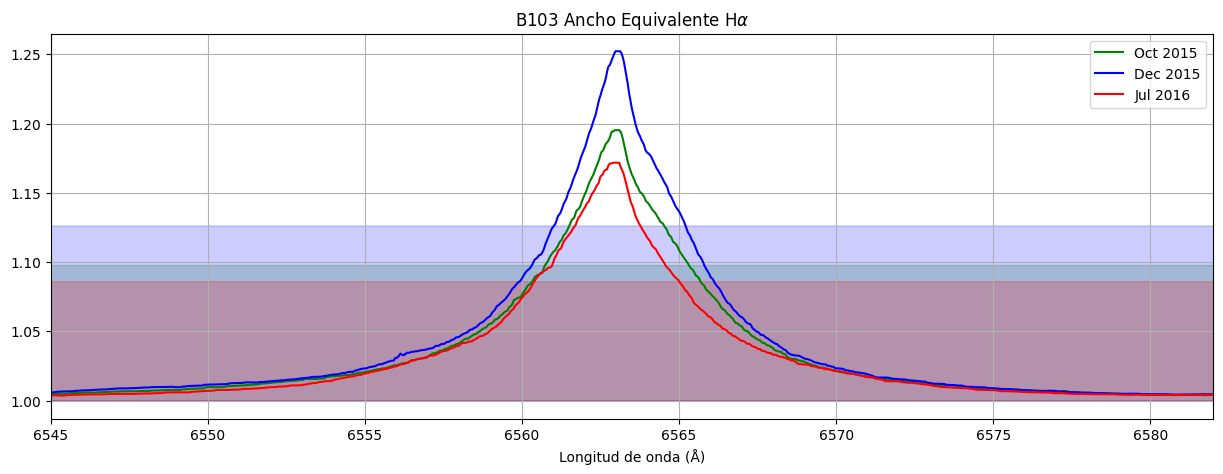

In [24]:
center_Oct, left_Oct, right_Oct, ew_Oct, ew_err_Oct = center_half_min_and_EW((lam1-3.3)[98900:-86000], (xd1_filt/modelo1(lam1))[98900:-86000])
center_Dec, left_Dec, right_Dec, ew_Dec, ew_err_Dec = center_half_min_and_EW((lam2-3.3)[98900:-86000], (xd2_filt/modelo2(lam2))[98900:-86000])
center_Jul, left_Jul, right_Jul, ew_Jul, ew_err_Jul = center_half_min_and_EW((lam3-3.3)[98900:-86000], (xd3_filt/modelo3(lam3))[98900:-86000])

print(f"Ancho equivalente Oct 2015: {ew_Oct:.6f} ± {ew_err_Oct:.6f}")
print(f"Ancho equivalente Dec 2015: {ew_Dec:.6f} ± {ew_err_Dec:.6f}")
print(f"Ancho equivalente Jul 2016: {ew_Jul:.6f} ± {ew_err_Jul:.6f}")


# Oct
x1 = (lam1 - 3.3)[98900:-86000]
y1 = (xd1_filt / modelo1(lam1))[98900:-86000]

# Dec
x2 = (lam2 - 3.3)[98900:-86000]
y2 = (xd2_filt / modelo2(lam2))[98900:-86000]

# Jul
x3 = (lam3 - 3.3)[98900:-86000]
y3 = (xd3_filt / modelo3(lam3))[98900:-86000]



plt.figure(figsize=(15, 5))
plt.plot(x1, y1, label='Oct 2015', color='green')
plt.plot(x2, y2, label='Dec 2015', color='blue')
plt.plot(x3, y3, label='Jul 2016', color='red')

cont = 1
half1 = cont + 0.5 * (np.max(y1) - cont)
half2 = cont + 0.5 * (np.max(y2) - cont)
half3 = cont + 0.5 * (np.max(y3) - cont)

# --- Plot all spectra with FWHM shading ---

# Fill each FWHM region individually
plt.fill_between(x1, half1, cont, where=(x1 >= left_Oct) & (x1 <= right_Oct),
                 color='green', alpha=0.2)
plt.fill_between(x2, half2, cont, where=(x2 >= left_Dec) & (x2 <= right_Dec),
                 color='blue', alpha=0.2)
plt.fill_between(x3, half3, cont, where=(x3 >= left_Jul) & (x3 <= right_Jul),
                 color='red', alpha=0.2)
plt.xlabel("Longitud de onda (Å)")
plt.xlim(6545,6582)
plt.legend()
plt.title(r"B103 Ancho Equivalente H$\alpha$")
plt.grid(True)
#plt.savefig('distance.png')

plt.show()

In [135]:
center_Dec

6498.819394775954

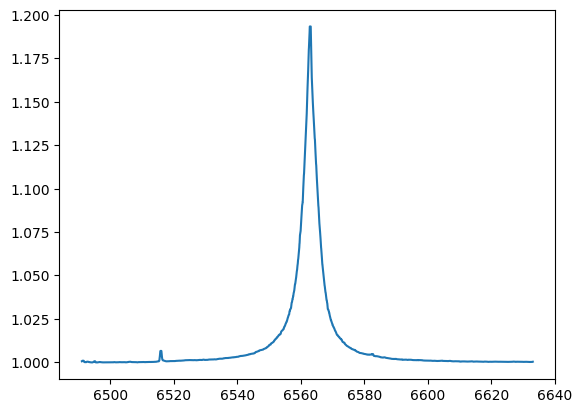

In [134]:
plt.plot((lam1-3.3)[98900:-86000], (xd1_filt/modelo1(lam1))[98900:-86000])